## CHATBOT WITH LANGGRAPH

### Here is a phase one in this phase one define some common notation

##### Here is my model

In [1]:
'''from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-1.0-pro")'''

from langchain_groq import ChatGroq
llm=ChatGroq(model_name="llama-3.1-8b-instant")

d:\Installation_path\ANACONDA\envs\genai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm.invoke("hello")

AIMessage(content='Hello. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.011669647, 'completion_tokens_details': None, 'prompt_time': 0.001665619, 'prompt_tokens_details': None, 'queue_time': 0.045116231, 'total_time': 0.013335266}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc53f-0ecf-7ea2-9516-d18960e1dd37-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [3]:
llm.invoke("hello").content

'Hello. How can I assist you today?'

##### This is all the import statement

In [4]:
from langgraph.graph import StateGraph,MessagesState, START, END
from langgraph.graph.message import add_messages
from typing import Annotated, Literal, TypedDict
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode

##### Here is a my call model Function

https://github.com/langchain-ai/langgraph/tree/main/libs/langgraph/langgraph/graph

In [5]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

#### Here is my workflow

In [6]:
workflow=StateGraph(MessagesState)
workflow.add_node("chatbot",call_model)
workflow.add_edge(START, "chatbot")
workflow.add_edge("chatbot",END)
app=workflow.compile()

#### Here is my visualization

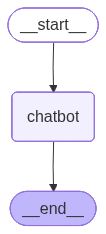

In [7]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

#### Here i am invoking the Graph

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [8]:
input={"messages":["hi, my name is Akshat"]}

In [9]:
app.invoke(input)

{'messages': [HumanMessage(content='hi, my name is Akshat', additional_kwargs={}, response_metadata={}, id='6d42a9bf-b164-4ca5-b8e2-1f016cf2416e'),
  AIMessage(content='Nice to meet you, Akshat. Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 43, 'total_tokens': 68, 'completion_time': 0.028753872, 'completion_tokens_details': None, 'prompt_time': 0.003327467, 'prompt_tokens_details': None, 'queue_time': 0.047257673, 'total_time': 0.032081339}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc53f-48da-7312-acb7-a543385727c6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 25, 'total_tokens': 68})]}

#### Here i am streaming the output

In [10]:
for output in app.stream(input):
    for key,value in output.items():
        print(f"Output from {key} Node")
        print("_______")
        print(value)
        print("\n")

Output from chatbot Node
_______
{'messages': [AIMessage(content='Nice to meet you, Akshat. Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 43, 'total_tokens': 68, 'completion_time': 0.025408575, 'completion_tokens_details': None, 'prompt_time': 0.003209989, 'prompt_tokens_details': None, 'queue_time': 0.046007989, 'total_time': 0.028618564}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc53f-50a6-7112-95be-317426e93f41-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 25, 'total_tokens': 68})]}




## starting phase2 from here with tool

##### Lets first add the custom tool

In [11]:
@tool
def search(query: str):
    """this is my custom tool."""
    if "sf" in query.lower() or "san francisco" in query.lower():
        return "It's 60 degrees and foggy."
    return "It's 90 degrees and sunny."

In [12]:
search.invoke("what is a temprature in sf?")

"It's 60 degrees and foggy."

In [13]:
search.invoke("what is a weather in india?")

"It's 90 degrees and sunny."

In [14]:
tools=[search]

In [15]:
tools

[StructuredTool(name='search', description='this is my custom tool.', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000002B3F9DA3E20>)]

In [16]:
tool_node=ToolNode(tools)

In [17]:
tool_node

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'search': StructuredTool(name='search', description='this is my custom tool.', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000002B3F9DA3E20>)}, _injected_args={'search': _InjectedArgs(state={}, store=None, runtime=None)}, _handle_tool_errors=<function _default_handle_tool_errors at 0x000002B3F9DA11B0>, _messages_key='messages', _wrap_tool_call=None, _awrap_tool_call=None)

In [36]:
llm_with_tool=llm.bind_tools(tools)

In [19]:
llm_with_tool.invoke("hi")

AIMessage(content='No specific function is available for this interaction.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 209, 'total_tokens': 219, 'completion_time': 0.028182902, 'completion_tokens_details': None, 'prompt_time': 0.01466998, 'prompt_tokens_details': None, 'queue_time': 0.04613699, 'total_time': 0.042852882}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc53f-86fc-7f92-8f5f-bc8b62fe284a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 209, 'output_tokens': 10, 'total_tokens': 219})

##### Here is a my call model binding with tool

In [37]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm_with_tool.invoke(messages)
    return {"messages": [response]}

In [21]:
response=call_model({"messages": ["hi how are you?"]})

In [22]:
response

{'messages': [AIMessage(content="I'm functioning properly, thank you for asking. Is there anything else I can assist you with?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 213, 'total_tokens': 234, 'completion_time': 0.030331651, 'completion_tokens_details': None, 'prompt_time': 0.012200857, 'prompt_tokens_details': None, 'queue_time': 0.044989913, 'total_time': 0.042532508}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc53f-a889-7971-9554-c5c9d9877df2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 213, 'output_tokens': 21, 'total_tokens': 234})]}

AIMessage(content='I am doing well, thank you. How can I help you?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 941, 'total_tokens': 957, 'completion_time': 0.029090909, 'prompt_time': 0.031196443, 'queue_time': 0.0032329660000000003, 'total_time': 0.060287352}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run-1db8fb5d-a8fd-4f85-8091-c2662bc18c22-0', usage_metadata={'input_tokens': 941, 'output_tokens': 16, 'total_tokens': 957})

##### Show the above output with the json viewer

In [25]:
messages = response['messages']

In [26]:
last_message=messages[-1]

In [27]:
last_message.tool_calls

[]

In [28]:
response=call_model({"messages": ["what is a weather in India?"]})

In [29]:
messages = response['messages']

In [30]:
last_message=messages[-1]

In [31]:
last_message.tool_calls

[]

#### Here is my Router Function

In [24]:
def router_function(state: MessagesState) -> Literal["tools", END]:
    #print(f"here is a state from should continue {state}")
    messages = state['messages']
    last_message = messages[-1]
    #print(f"here is a last message from should continue {last_message}")
    if last_message.tool_calls:
        return "tools"
    return END

### lets design the workflow now

In [25]:
workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")

workflow.add_conditional_edges(
    "agent",
    router_function,
    {"tools": "tools", END: END}
)

workflow.add_edge("tools", "agent")

app = workflow.compile()

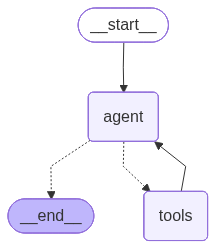

In [26]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [29]:
from langchain_core.messages import HumanMessage
app.invoke({"messages": [HumanMessage(content="hi how are you?")]})

{'messages': [HumanMessage(content='hi how are you?', additional_kwargs={}, response_metadata={}, id='4703937d-df32-4e06-bbd0-553d7b8c409b'),
  AIMessage(content="I'm functioning properly, thank you for asking. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 213, 'total_tokens': 231, 'completion_time': 0.028347364, 'completion_tokens_details': None, 'prompt_time': 0.013394553, 'prompt_tokens_details': None, 'queue_time': 0.045639436, 'total_time': 0.041741917}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc542-0e27-7991-99de-7ddc34656f62-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 213, 'output_tokens': 18, 'total_tokens': 231})]}

In [33]:
app.invoke({"messages": ["hi how are you?"]})

{'messages': [HumanMessage(content='hi how are you?', additional_kwargs={}, response_metadata={}, id='b029d94f-248a-432d-b5e5-f2ee37528f71'),
  AIMessage(content="I'm functioning within normal parameters. What can I assist you with today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 213, 'total_tokens': 229, 'completion_time': 0.02784829, 'completion_tokens_details': None, 'prompt_time': 0.014404753, 'prompt_tokens_details': None, 'queue_time': 0.046104417, 'total_time': 0.042253043}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc543-4561-72c2-8118-d296b189defb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 213, 'output_tokens': 16, 'total_tokens': 229})]}

In [31]:
app.invoke({"messages": ["what is the weather in sf"]})

{'messages': [HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='843fab8f-4792-466b-b2eb-ac93e487553f'),
  AIMessage(content="I'm sorry, I don't know the current weather in San Francisco.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 214, 'total_tokens': 230, 'completion_time': 0.031540421, 'completion_tokens_details': None, 'prompt_time': 0.014080744, 'prompt_tokens_details': None, 'queue_time': 0.045392865, 'total_time': 0.045621165}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc542-9e7d-70d0-8419-506b9bef7e1e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 214, 'output_tokens': 16, 'total_tokens': 230})]}

In [38]:
from langchain_core.messages import HumanMessage

for output in app.stream({"messages": [HumanMessage(content="what is the weather in sf")]}):
    for key, value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from agent
_______
{'messages': [AIMessage(content='<brave_search>weather in SF</brave_search>', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 214, 'total_tokens': 227, 'completion_time': 0.028110566, 'completion_tokens_details': None, 'prompt_time': 0.040890801, 'prompt_tokens_details': None, 'queue_time': 0.045126452, 'total_time': 0.069001367}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc545-79fe-7f23-a0be-29db395e2b87-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 214, 'output_tokens': 13, 'total_tokens': 227})]}




#### Lets create a loop now

In [51]:
workflow.add_edge("tools", 'agent')


Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [52]:
app = workflow.compile()

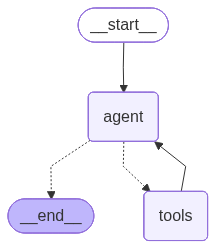

In [53]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [61]:
for output in app.stream({"messages": ["what is the weather in sf"]}):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from agent
_______
{'messages': [AIMessage(content='<brave_search> {"query": "sf weather"}', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 214, 'total_tokens': 226, 'completion_time': 0.029193764, 'completion_tokens_details': None, 'prompt_time': 0.012309974, 'prompt_tokens_details': None, 'queue_time': 0.045673076, 'total_time': 0.041503738}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc53a-f84f-7153-bf5d-3e4dceab523f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 214, 'output_tokens': 12, 'total_tokens': 226})]}




#### Strating Phase 3 from here with memory and checkpointing

In [84]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [85]:
# Define a new graph
workflow3 = StateGraph(MessagesState)

workflow3.add_node("agent", call_model)
workflow3.add_node("tools", tool_node)

workflow3.add_edge(START, "agent")

workflow3.add_conditional_edges("agent",router_function,{"tools": "tools", END: END})

workflow3.add_edge("tools", 'agent')

app3 = workflow3.compile(checkpointer = memory)

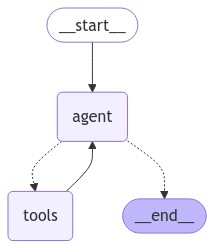

In [86]:
from IPython.display import Image, display

try:
    display(Image(app3.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [87]:
config = {"configurable": {"thread_id": "1"}}

In [91]:
events = app3.stream(
    {"messages": ["Hi there! My name is Sunny."]}, config, stream_mode="values"
)

In [92]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is Sunny.
================================== Ai Message ==================================

Nice to meet you, Sunny! What can I do for you today?


In [93]:
events = app3.stream(
    {"messages": ["can you tell me what was my name?"]}, config, stream_mode="values"
)

In [94]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

can you tell me what was my name?
================================== Ai Message ==================================

Your name is Sunny.


In [95]:
config

{'configurable': {'thread_id': '1'}}

In [97]:
memory.get(config)

{'v': 1,
 'ts': '2024-10-28T12:47:51.236640+00:00',
 'id': '1ef952ad-7bc1-6146-800b-f04ab365d30a',
 'channel_values': {'messages': [HumanMessage(content='Hi there! My name is Sunny.', additional_kwargs={}, response_metadata={}, id='7889328e-cfbf-4b15-8176-58243ae5809f'),
   AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_1vgr', 'function': {'arguments': '{"query":"My name is Sunny"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 944, 'total_tokens': 1027, 'completion_time': 0.150909091, 'prompt_time': 0.03833481, 'queue_time': 0.003830514, 'total_time': 0.189243901}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-863768b4-61cb-4147-98ba-c69916ec52c6-0', tool_calls=[{'name': 'search', 'args': {'query': 'My name is Sunny'}, 'id': 'call_1vgr', 'type': 'tool_call'}], usage_metadata={'input_tokens': 944, 'output_tokens

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults
tool = TavilySearchResults(max_results=2)
tools = [tool]
tool.invoke("What's a 'node' in LangGraph?")